In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()
import os

In [3]:
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.3, max_tokens=2000
    )

llm = get_groq_llm()

In [4]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str


In [5]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [6]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [7]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

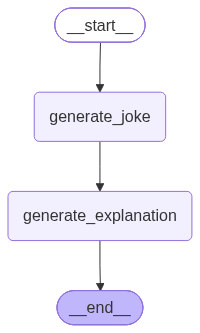

In [8]:
workflow

In [9]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄',
 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Pizza as a character** | The joke turns a pizza into a person who can *apply for a job*. | Anthropomorphism (giving human traits to inanimate objects) is a classic comedic device. It immediately sets up a silly, absurd premise. |\n| **“Crust”** | The outer edge of a pizza. | It’s the pizza’s “thing” that can be used in a pun. |\n| **“Get a living”** | A common phrase meaning “earn money” or “make a living.” | It’s the goal of most job‑seekers. |\n| **Pun: “crust of a living”** | A play on the phrase “cost of living.” | 1. **Sound‑alike**: “crust” and “cost” are close in sound, especially in casual speech. 2. **Word‑play**: The pizza is literally using its crust to earn a living, so the phrase becomes “crust” instead o

In [10]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Pizza as a character** | The joke turns a pizza into a person who can *apply for a job*. | Anthropomorphism (giving human traits to inanimate objects) is a classic comedic device. It immediately sets up a silly, absurd premise. |\n| **“Crust”** | The outer edge of a pizza. | It’s the pizza’s “thing” that can be used in a pun. |\n| **“Get a living”** | A common phrase meaning “earn money” or “make a living.” | It’s the goal of most job‑seekers. |\n| **Pun: “crust of a living”** | A play on the phrase “cost of living.” | 1. **Sound‑alike**: “crust” and “cost” are close in sound, especially in casual speech. 2. **Word‑play**: The pizza is literally using its crust to earn a living, so the phrase become

# ## Intermediate States

In [11]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Pizza as a character** | The joke turns a pizza into a person who can *apply for a job*. | Anthropomorphism (giving human traits to inanimate objects) is a classic comedic device. It immediately sets up a silly, absurd premise. |\n| **“Crust”** | The outer edge of a pizza. | It’s the pizza’s “thing” that can be used in a pun. |\n| **“Get a living”** | A common phrase meaning “earn money” or “make a living.” | It’s the goal of most job‑seekers. |\n| **Pun: “crust of a living”** | A play on the phrase “cost of living.” | 1. **Sound‑alike**: “crust” and “cost” are close in sound, especially in casual speech. 2. **Word‑play**: The pizza is literally using its crust to earn a living, so the phrase becom

In [12]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy?\n\nBecause it had too many *twists* in its life and couldn’t *pasta* the stress!',
 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it’s doing | Why it’s funny |\n|---------|-----------------|----------------|\n| **Anthropomorphism** | The spaghetti is treated like a person who can feel stress, have a “life,” and need therapy. | It’s absurd to imagine a noodle with emotions, which immediately sets up a comedic contrast. |\n| **“Twists”** | 1. *Literal*: Spaghetti is a long, twisted noodle.<br>2. *Figurative*: Life can have “twists” (plot twists, unexpected turns). | The double meaning lets the punchline play on both the noodle’s shape and the idea of a complicated life. |\n| **“Pasta” as a verb** | The line “couldn’t *pasta* the stress” sounds like “couldn’t *past* the stress” or “couldn’t *pass* the stress.” | It’s a classic pun: turning the noun *pasta* into a verb, which is grammatically

In [13]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy?\n\nBecause it had too many *twists* in its life and couldn’t *pasta* the stress!', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it’s doing | Why it’s funny |\n|---------|-----------------|----------------|\n| **Anthropomorphism** | The spaghetti is treated like a person who can feel stress, have a “life,” and need therapy. | It’s absurd to imagine a noodle with emotions, which immediately sets up a comedic contrast. |\n| **“Twists”** | 1. *Literal*: Spaghetti is a long, twisted noodle.<br>2. *Figurative*: Life can have “twists” (plot twists, unexpected turns). | The double meaning lets the punchline play on both the noodle’s shape and the idea of a complicated life. |\n| **“Pasta” as a verb** | The line “couldn’t *pasta* the stress” sounds like “couldn’t *past* the stress” or “couldn’t *pass* the stress.” | It’s a classic pun: turning the noun *pasta* into a verb, whi

In [14]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy?\n\nBecause it had too many *twists* in its life and couldn’t *pasta* the stress!', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it’s doing | Why it’s funny |\n|---------|-----------------|----------------|\n| **Anthropomorphism** | The spaghetti is treated like a person who can feel stress, have a “life,” and need therapy. | It’s absurd to imagine a noodle with emotions, which immediately sets up a comedic contrast. |\n| **“Twists”** | 1. *Literal*: Spaghetti is a long, twisted noodle.<br>2. *Figurative*: Life can have “twists” (plot twists, unexpected turns). | The double meaning lets the punchline play on both the noodle’s shape and the idea of a complicated life. |\n| **“Pasta” as a verb** | The line “couldn’t *pasta* the stress” sounds like “couldn’t *past* the stress” or “couldn’t *pass* the stress.” | It’s a classic pun: turning the noun *pasta* into a verb, wh

# ### Time Travel
# 
# ## we can go back to any previous node to do the execution again for debugging & changing the input as well


## so let's go to the pizza example where we got the topic & we want to go back to joke generation step & further steps.
## In order to do that we need to grab the checkpoint id where we got the topic. We can get it from the state history.


In [15]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy?\n\nBecause it had too many *twists* in its life and couldn’t *pasta* the stress!', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it’s doing | Why it’s funny |\n|---------|-----------------|----------------|\n| **Anthropomorphism** | The spaghetti is treated like a person who can feel stress, have a “life,” and need therapy. | It’s absurd to imagine a noodle with emotions, which immediately sets up a comedic contrast. |\n| **“Twists”** | 1. *Literal*: Spaghetti is a long, twisted noodle.<br>2. *Figurative*: Life can have “twists” (plot twists, unexpected turns). | The double meaning lets the punchline play on both the noodle’s shape and the idea of a complicated life. |\n| **“Pasta” as a verb** | The line “couldn’t *pasta* the stress” sounds like “couldn’t *past* the stress” or “couldn’t *pass* the stress.” | It’s a classic pun: turning the noun *pasta* into a verb, wh

In [16]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Pizza as a character** | The joke turns a pizza into a person who can *apply for a job*. | Anthropomorphism (giving human traits to inanimate objects) is a classic comedic device. It immediately sets up a silly, absurd premise. |\n| **“Crust”** | The outer edge of a pizza. | It’s the pizza’s “thing” that can be used in a pun. |\n| **“Get a living”** | A common phrase meaning “earn money” or “make a living.” | It’s the goal of most job‑seekers. |\n| **Pun: “crust of a living”** | A play on the phrase “cost of living.” | 1. **Sound‑alike**: “crust” and “cost” are close in sound, especially in casual speech. 2. **Word‑play**: The pizza is literally using its crust to earn a living, so the phrase becom

In [17]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1a9de5-b834-631c-8000-47051f819623"}}) ## checkpoint id from pizza run where we haver the topic but we need to generate the joke


StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1a9de5-b834-631c-8000-47051f819623'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-06T10:33:10.835885+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a9de5-b830-6708-bfff-1bb74c021cc1'}}, tasks=(PregelTask(id='08101c0d-32b9-dfac-cc67-9de6a717f0d2', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄'}),), interrupts=())

In [18]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1a9de5-b834-631c-8000-47051f819623"}})


{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄',
 'explanation': ''}

# ## now we can see more Snapshots due to the re-execution

In [19]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': ''}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a9e03-f166-66c6-8003-79ca5f75b8cf'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-09-06T10:46:42.139689+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a9e03-da76-60a6-8002-97d35b2c7fc7'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a9e03-da76-60a6-8002-97d35b2c7fc7'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-09-06T10:46:39.734381+00:00', parent_config={'configurable': {'thread_id': '1', 

# #### Updating State

In [20]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1a9de5-b834-631c-8000-47051f819623", "checkpoint_ns": ""}}, {'topic':'Burger'})


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1a9e0b-b2b5-6fc8-8001-bcffabc7f694'}}

# ## now we have updated the state with topic as samosa, one more snapshot will be created

In [21]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Burger'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a9e0b-b2b5-6fc8-8001-bcffabc7f694'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-09-06T10:50:10.314628+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a9de5-b834-631c-8000-47051f819623'}}, tasks=(PregelTask(id='187f2ea2-41cc-78ff-9b2a-37d52951c00a', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': ''}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a9e03-f166-66c6-8003-79ca5f75b8cf'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-09-06T10:46:42.

# ## and to execute the workflow from the updated state (samosa) we need to pass the checkpoint id of samosa snapshot



In [22]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1a9e0b-b2b5-6fc8-8001-bcffabc7f694"}})


{'topic': 'Burger',
 'joke': 'Why did the burger go to therapy?\n\nBecause it felt *lettuce* it was just a *meat* of its own problems!',
 'explanation': '**Why the joke works**\n\n1. **Anthropomorphism** – The burger is given a human problem (“feeling bad”) and a human solution (therapy). That sets up a silly, unexpected scenario.\n\n2. **Ingredient‑pun** – The punchline plays on the two main ingredients of a burger: **lettuce** and **meat**.  \n   * “Lettuce” sounds like **“let us.”**  \n   * “Meat” sounds like **“meet.”**\n\n3. **Word‑play sentence** – The line “Because it felt *lettuce* it was just a *meat* of its own problems!” is a pun on the phrase **“let us meet.”**  \n   * In the joke, the burger is saying it feels like it’s *the cause* of its own problems (“just a meat of its own problems”), while the literal ingredients (lettuce and meat) make the phrase sound like “let us meet.”\n\n4. **Double meaning** –  \n   * **Literal:** The burger is literally made of lettuce and meat.

In [23]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Burger', 'joke': 'Why did the burger go to therapy?\n\nBecause it felt *lettuce* it was just a *meat* of its own problems!', 'explanation': '**Why the joke works**\n\n1. **Anthropomorphism** – The burger is given a human problem (“feeling bad”) and a human solution (therapy). That sets up a silly, unexpected scenario.\n\n2. **Ingredient‑pun** – The punchline plays on the two main ingredients of a burger: **lettuce** and **meat**.  \n   * “Lettuce” sounds like **“let us.”**  \n   * “Meat” sounds like **“meet.”**\n\n3. **Word‑play sentence** – The line “Because it felt *lettuce* it was just a *meat* of its own problems!” is a pun on the phrase **“let us meet.”**  \n   * In the joke, the burger is saying it feels like it’s *the cause* of its own problems (“just a meat of its own problems”), while the literal ingredients (lettuce and meat) make the phrase sound like “let us meet.”\n\n4. **Double meaning** –  \n   * **Literal:** The burger is literally made 

# ### Fault Tolerance kind of similar as human in the loop (In HITL we do it perpupose fully using langraph interrupt)

In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [ ]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [ ]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(10)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"step3": "done"}


In [ ]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
graph

In [ ]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")


In [ ]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

In [ ]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)



In [26]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

AttributeError: 'StateGraph' object has no attribute 'get_state_history'